In [43]:
import argparse
import os
import re
import fnmatch
from typing import Dict, List, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pickle
# Configure matplotlib fonts
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 12

In [57]:
actions = [
    "cartesian_position",
    "joint_position",
    "joint_velocity"
] 

In [58]:
use_prop = False

In [59]:
folder_path = "/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/"

In [138]:
action = actions[0]

In [139]:
file_paths = [
    os.path.join(folder_path, f"{action}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
    for i in range(10)
]
print(file_paths)

['/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_False_trial_0.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_False_trial_1.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_False_trial_2.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_False_trial_3.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_False_trial_4.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_False_trial_5.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_False_trial_6.pkl.csv', '/home/sazimi/Desktop/ICRA2026/training/sim_to_real/real_franka_eval_logs/cartesian_position_use_prop_False_trial_7.p

In [140]:
df = pd.read_csv(f"{folder_path}/cartesian_position_use_prop_False_trial_0_success.pkl.csv")
df

,t,success,grasped,has_collided,joint_jerks,proprioception
0,0,False,False,False,0.422980,[-0.012 0.231 0.014 -2.12 -0.007 2.335 0....
1,1,False,False,False,1.553835,[-0.012 0.231 0.014 -2.12 -0.007 2.335 0....
2,2,False,False,False,66.515977,[-0.015 0.23 0.015 -2.121 -0.007 2.337 0....
3,3,False,False,False,68.692502,[-0.017 0.23 0.018 -2.123 -0.008 2.338 0....
4,4,False,False,False,23.449340,[-0.02 0.23 0.02 -2.125 -0.008 2.34 0....
...,...,...,...,...,...,...
495,495,False,True,False,10.101025,[-0.635 0.472 0.421 -2.117 -0.31 2.501 0....
496,496,False,True,False,12.123544,[-0.639 0.471 0.424 -2.118 -0.312 2.5 0....
497,497,False,True,False,14.254493,[-0.642 0.47 0.427 -2.118 -0.313 2.499 0....
498,498,False,True,False,13.068997,[-0.645 0.469 0.429 -2.119 -0.314 2.499 0....


In [141]:
dfs = []
for path in file_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        # Extract trial number from filename using regex
        match = re.search(r"trial_(\d+)", os.path.basename(path))
        trial = int(match.group(1)) if match else None
        df['trial'] = trial
        dfs.append(df)

all_results = pd.concat(dfs, ignore_index=True)
all_results

,t,success,grasped,has_collided,joint_jerks,proprioception,trial
0,0,False,False,False,1.045595,[-0.014 0.23 0.015 -2.12 -0.008 2.336 0....,0
1,1,False,False,False,1.602052,[-0.014 0.23 0.015 -2.12 -0.008 2.336 0....,0
2,2,False,False,False,55.608116,[-0.016 0.23 0.017 -2.121 -0.008 2.337 0....,0
3,3,False,False,False,50.831009,[-0.018 0.23 0.019 -2.123 -0.008 2.339 0....,0
4,4,False,False,False,21.734325,[-0.021 0.23 0.021 -2.125 -0.009 2.341 0....,0
...,...,...,...,...,...,...,...
7495,445,False,True,False,152.702055,[-0.144 0.383 0.105 -2.188 -0.061 2.547 0....,9
7496,446,False,True,False,73.739325,[-0.147 0.382 0.106 -2.189 -0.063 2.546 0....,9
7497,447,False,True,False,17.465976,[-0.15 0.38 0.108 -2.19 -0.064 2.546 0....,9
7498,448,False,True,False,35.889177,[-0.152 0.379 0.11 -2.191 -0.065 2.545 0....,9


In [142]:
all_results.groupby('trial')['success'].any().mean() * 100

np.float64(70.0)

In [143]:
trial_stats = all_results.groupby('trial').agg(
    num_collisions=('has_collided', 'sum'),
    trial_length=('has_collided', 'count')
)
trial_stats['trial_collision_rate'] = trial_stats['num_collisions'] / trial_stats['trial_length']
trial_stats

,num_collisions,trial_length,trial_collision_rate
trial,,,
0,0,450,0.000000
1,0,500,0.000000
2,0,400,0.000000
3,0,1000,0.000000
4,53,550,0.096364
5,87,850,0.102353
6,0,450,0.000000
7,0,1350,0.000000
8,0,1500,0.000000


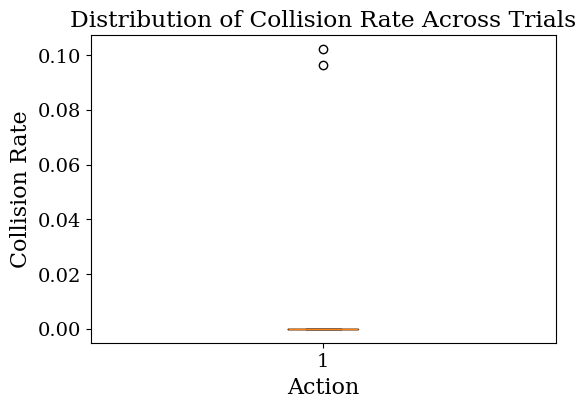

In [144]:
import matplotlib.pyplot as plt

# Assuming 'trial_stats' is your DataFrame and the final column is 'grasps_per_length'
plt.figure(figsize=(6, 4))
plt.boxplot(trial_stats['trial_collision_rate'].dropna())
plt.xlabel('Action')
plt.ylabel('Collision Rate')
plt.title('Distribution of Collision Rate Across Trials')
plt.show()

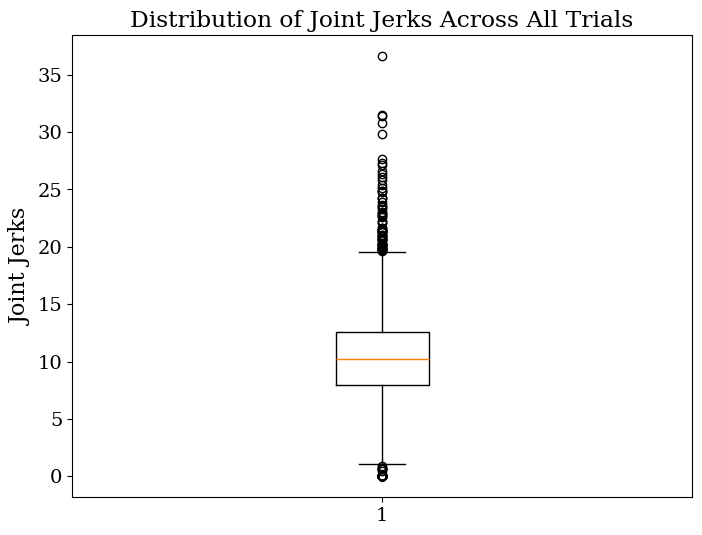

In [117]:
plt.figure(figsize=(8, 6))
plt.boxplot(all_results['joint_jerks'].dropna())
plt.ylabel('Joint Jerks')
plt.title('Distribution of Joint Jerks Across All Trials')
plt.show()

In [153]:
results = {}
for act in actions:
    file_paths = [
        os.path.join(folder_path, f"{act}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
        for i in range(10)
    ]
    dfs = []
    for path in file_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            match = re.search(r"trial_(\d+)", os.path.basename(path))
            trial = int(match.group(1)) if match else None
            df['trial'] = trial
            dfs.append(df)
    if dfs:
        all_results = pd.concat(dfs, ignore_index=True)
        success_rate = all_results.groupby('trial')['success'].any().mean() * 100
        
        results[act] = success_rate
    else:
        results[act] = None
# Show bar plot of success rates for each action
results_df = pd.DataFrame(list(results.items()), columns=['action', 'success_rate'])
results_df.to_csv('success_rates_by_action.csv', index=False)

/tmp/ipykernel_1353262/1962241824.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(collision_rates, labels=labels, showfliers=False)


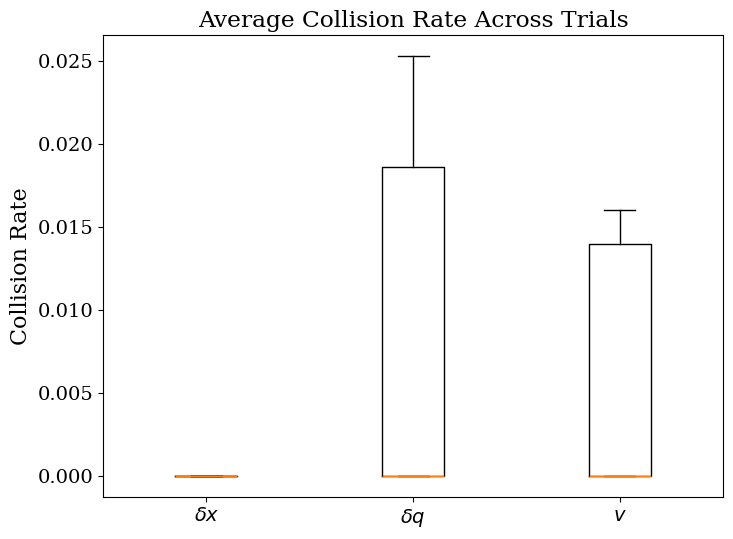

In [149]:
plt.figure(figsize=(8, 6))
collision_rates = []
labels = []
for act in actions:
    file_paths = [
        os.path.join(folder_path, f"{act}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
        for i in range(10)
    ]
    dfs = []
    for path in file_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            match = re.search(r"trial_(\d+)", os.path.basename(path))
            trial = int(match.group(1)) if match else None
            df['trial'] = trial
            dfs.append(df)
    if dfs:
        all_results = pd.concat(dfs, ignore_index=True)
        trial_stats = all_results.groupby('trial').agg(
            num_collisions=('has_collided', 'sum'),
            trial_length=('has_collided', 'count')
        )
        trial_stats['trial_collision_rate'] = (trial_stats['num_collisions'] / trial_stats['trial_length'])
        collision_rates.append(trial_stats['trial_collision_rate'].dropna())
        labels.append(act)
labels = [r"$\delta x$", r"$\delta q$", r"$v$"]
plt.boxplot(collision_rates, labels=labels, showfliers=False)
plt.ylabel('Collision Rate')
# plt.ylim(0, 0.1) 
plt.title('Average Collision Rate Across Trials')
plt.savefig("collision_rate_distribution_across_actions.pdf", format="pdf", bbox_inches="tight")
plt.show()



In [ ]:
plt.figure(figsize=(8, 6))
collision_rates = []
labels = []
for act in actions:
    file_paths = [
        os.path.join(folder_path, f"{act}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
        for i in range(10)
    ]
    dfs = []
    for path in file_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            match = re.search(r"trial_(\d+)", os.path.basename(path))
            trial = int(match.group(1)) if match else None
            df['trial'] = trial
            dfs.append(df)
    if dfs:
        all_results = pd.concat(dfs, ignore_index=True)
        trial_stats = all_results.groupby('trial').agg(
            num_collisions=('has_collided', 'sum'),
            trial_length=('has_collided', 'count')
        )
        trial_stats['trial_collision_rate'] = trial_stats['num_collisions'] / trial_stats['trial_length']
        collision_rates.append(trial_stats['trial_collision_rate'].dropna())
        labels.append(act)

plt.boxplot(collision_rates, labels=labels)
plt.ylabel('Collision Rate')
# plt.ylim(0, 0.1) 
plt.title('Collision Rate Distribution Across Actions')
plt.show()

/tmp/ipykernel_1353262/3841686668.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(joint_jerks_data, labels=actions)


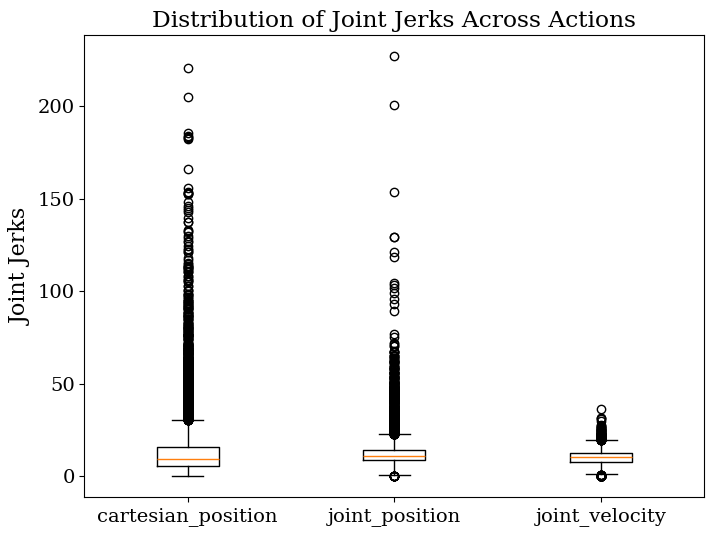

In [ ]:
plt.figure(figsize=(8, 6))
joint_jerks_data = []
for act in actions:
    file_paths = [
        os.path.join(folder_path, f"{act}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
        for i in range(10)
    ]
    dfs = []
    for path in file_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            dfs.append(df)
    if dfs:
        all_results = pd.concat(dfs, ignore_index=True)
        joint_jerks_data.append(all_results['joint_jerks'].dropna())

plt.boxplot(joint_jerks_data, labels=actions)
plt.ylabel('Joint Jerks')
# plt.ylim(0,40)
plt.title('Distribution of Joint Jerks Across Actions')
plt.show()

In [118]:
average_jerks = []
for jerks in joint_jerks_data:
    avg = jerks.mean()
    average_jerks.append(avg)

for label, avg in zip(labels, average_jerks):
    print(f"Average joint jerk for {label}: {avg:.3f}")

Average joint jerk for cartesian_position: 14.925
Average joint jerk for joint_position: 12.874
Average joint jerk for joint_velocity: 10.343


/tmp/ipykernel_1353262/2317215244.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(collision_rates, labels=labels)


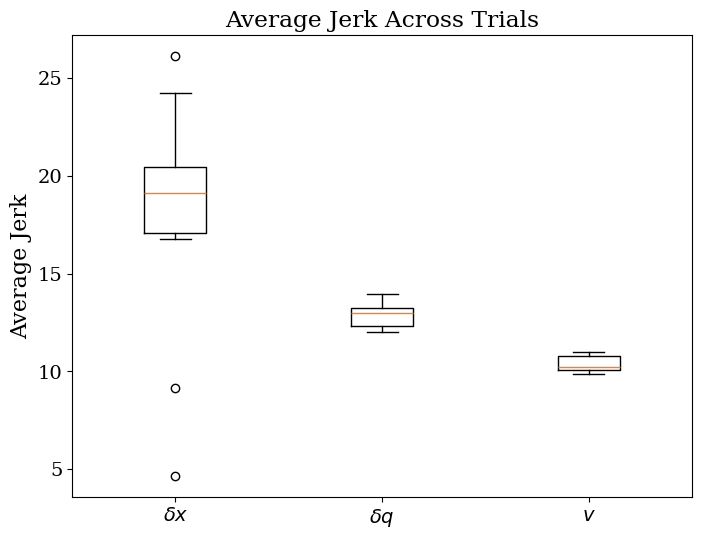

In [148]:
plt.figure(figsize=(8, 6))
collision_rates = []
labels = []
for act in actions:
    file_paths = [
        os.path.join(folder_path, f"{act}_use_prop_{str(use_prop)}_trial_{i}.pkl.csv")
        for i in range(10)
    ]
    dfs = []
    for path in file_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            match = re.search(r"trial_(\d+)", os.path.basename(path))
            trial = int(match.group(1)) if match else None
            df['trial'] = trial
            dfs.append(df)
    if dfs:
        all_results = pd.concat(dfs, ignore_index=True)
        trial_stats = all_results.groupby('trial').agg(
            jerks=('joint_jerks', 'mean')
        )
        collision_rates.append(trial_stats['jerks'].dropna())
        labels.append(act)
# To use LaTeX in matplotlib labels, wrap your label strings with r"$...$"
labels = [r"$\delta x$", r"$\delta q$", r"$v$"]
plt.boxplot(collision_rates, labels=labels)
plt.ylabel('Average Jerk')
# plt.xlim(0, 0.1) 

plt.title('Average Jerk Across Trials')
plt.savefig("average_jerk_distribution_across_actions.pdf")
plt.show()